In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch
import os
import numpy as np
import faiss
from typing import List, Tuple
import json
from sklearn.metrics import accuracy_score
from tqdm import tqdm

/home/vladg00dman/miniconda3/envs/NLP_ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

with pd.ExcelFile('data/data.xlsx') as xls:
    sheets_dict = {sheet: pd.read_excel(xls, sheet_name=sheet) for sheet in xls.sheet_names}

sheets_dict.keys()

dict_keys(['Популярные фразы', 'Вопрос ответ', 'Глоссарий'])

In [3]:
df_pph = sheets_dict['Популярные фразы']
df_qa = sheets_dict['Вопрос ответ']
df_dict = sheets_dict['Глоссарий']

In [4]:
glossary = dict(zip(df_dict['Сокращение'].to_list(), df_dict['Расшифровка'].to_list()))

In [5]:
with open("glossary.json", "w", encoding="utf-8") as f:
    json.dump(glossary, f, ensure_ascii=False, indent=4)

In [6]:
df_pph.head()

,Ответ,Вопрос
0,Для оформления обращения в техническую поддерж...,выйти
1,Чат-бот находится в стадии пилотирования и обу...,Уберите этот чат бот он очень мешает
2,Чат-бот находится в стадии пилотирования и обу...,вернуть старый дизайн
3,Для оформления обращения в техническую поддерж...,хочу создать заявку
4,Для оформления обращения в техническую поддерж...,мне нужно создать заявку


In [7]:
df_qa.head()

,Unnamed: 0,question,content,category
0,0,"Я сменил автомобить, на учет еще не поставил, ...",Для внесения данных по личному автомобилю обра...,автомобиль
1,1,Не отображается автомобиль в личном кабинете.,Для внесения данных по личному автомобилю обра...,автомобиль
2,2,добавить автомобиль,Для внесения данных по личному автомобилю обра...,автомобиль
3,3,хочу внести данные об автомобиле,Для внесения данных по личному автомобилю обра...,автомобиль
4,4,Как внести данные об автомобиле?,Для внесения данных по личному автомобилю обра...,автомобиль


In [8]:
df_dict.head()

,Сокращение,Расшифровка
0,лк,личный кабинет
1,БиР,Беременность и роды
2,зп,заработная плата
3,НДФЛ,Налог на доходы физических лиц
4,СТД,срочный трудовой договор


In [9]:
df_pph['Ответ'].unique()

array(['Для оформления обращения в техническую поддержку вам необходимо нажать на кнопку "Выйти из чата" или позвонить по номеру доб.10-100, прямой +7 (XXX) XXX XX XX.',
       'Чат-бот находится в стадии пилотирования и обучается ежедневно. Пожалуйста, обратитесь в поддержку или попробуйте переформулировать свой запрос'],
      dtype=object)

In [10]:
df_qa['content'].unique()

array(['Для внесения данных по личному автомобилю обратитесь, пожалуйста, к своему руководителю для создания заявки по теме "Изменение режима характера работы", подтема "Установка РХР и топливной карты". В комментариях опишите ситуацию и приложите ПТС, СТС, страховой полис и водительское удостоверение.',
       'Сотруднику следует обратиться в мед. организацию (по месту прописки) с данными документами для выдачи больничного листа российского образца. Оплата больничного листа возможна только на основании листа нетрудоспособности российского образца.',
       'Пожалуйста, обратитесь к непосредственному руководителю, чтобы он создал заявку в Личном кабинете https://company-x5.ru или приложении "Моя работа" в разделе "Декрет", "Администрирование отпуска БИР".',
       'Сотруднику следует обратиться к непосредственному руководителю, чтобы он создал заявку в Личном кабинете https://company-x5.ru или приложении "Моя работа" в разделе "Декрет", "Администрирование отпуска БИР".',
       'Обрати

In [11]:
content_vc = df_qa['content'].value_counts()

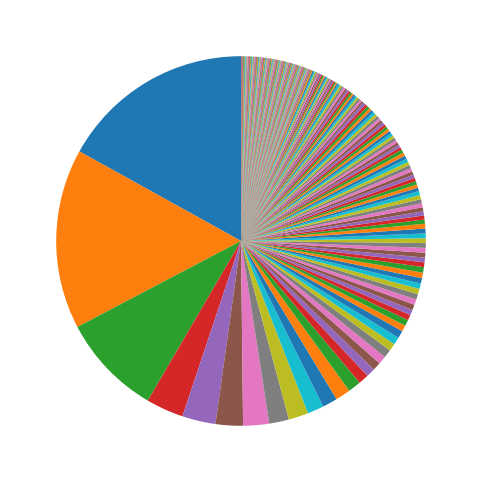

In [12]:
content_vc.plot.pie(
    figsize=(6, 6),
    labels=None,
    legend=False,
    startangle=90,
)

plt.ylabel('')
plt.show()

In [13]:
np.median(content_vc.values), np.mean(content_vc.values)

(np.float64(2.0), np.float64(7.415929203539823))

In [14]:
for i in df_pph['Ответ'].unique().tolist():
    print(i, i in df_qa['content'].unique().tolist())

Для оформления обращения в техническую поддержку вам необходимо нажать на кнопку "Выйти из чата" или позвонить по номеру доб.10-100, прямой +7 (XXX) XXX XX XX. True
Чат-бот находится в стадии пилотирования и обучается ежедневно. Пожалуйста, обратитесь в поддержку или попробуйте переформулировать свой запрос False


In [15]:
questions = df_qa['question'].to_list() + df_pph['Вопрос'].to_list()
answers = df_qa['content'].to_list() + df_pph['Ответ'].to_list()

q_a = dict(zip(questions, answers))


In [16]:
# model = SentenceTransformer("Tochka-AI/ruRoPEBert-e5-base-2k")

# question_embeddings = model.encode(questions, convert_to_tensor=False, show_progress_bar=True)

In [17]:
model_name = "Tochka-AI/ruRoPEBert-e5-base-2k"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, 
                         return_tensors="pt", max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        # Усреднение по токенам
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)


Some weights of BertModel were not initialized from the model checkpoint at Tochka-AI/ruRoPEBert-e5-base-2k and are newly initialized: ['embeddings.position_embeddings.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
question_embeddings = get_embeddings(questions)

100%|██████████| 53/53 [01:38<00:00,  1.85s/it]


In [19]:
question_embeddings = question_embeddings.astype('float32')
faiss.normalize_L2(question_embeddings)

# Создание индекса
index = faiss.IndexFlatIP(question_embeddings.shape[1])
index.add(question_embeddings)

new_question = "как зайти в лк"

# Поиск
query_embedding = get_embeddings([new_question])
query_embedding = query_embedding.astype('float32')
faiss.normalize_L2(query_embedding.reshape(1, -1))

D, I = index.search(query_embedding, k=1)  # Топ-1 результат
print(f"Ближайший вопрос: {questions[I[0][0]]} (сходство: {D[0][0]:.2f})")
print(f"Ответ: {q_a[questions[I[0][0]]]}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 13.90it/s]

Ближайший вопрос: не могу зайти в лк (сходство: 0.69)
Ответ: При проблемах со входом в личный кабинет, прежде чем создавать заявку в поддержку, убедитесь, что заходите в ЛК на сайте https://company-x5.ru, указываете актуальные и верные логин и пароль. Если Вам неизвестен логин, обратитесь к руководителю (ДМ), он сможет посмотреть Ваш логин и сбросить пароль в веб-табеле. Для самостоятельного сброса пароля позвоните с вашего мобильного телефона на +7 (XXX) XXX XX XX, наберите добавочный номер 10100, нажмите * и подтвердите сброс пароля, нажав #. Обновленный пароль отправляется по SMS.


In [22]:
def get_answer(text):
    query_embedding = get_answer([text])
    query_embedding = query_embedding.astype('float32')
    faiss.normalize_L2(query_embedding.reshape(1, -1))

    D, I = index.search(query_embedding, k=1)

    return q_a[questions[I[0][0]]]

In [ ]:
get_answer("Хочу срать")


KeyboardInterrupt



In [ ]:
faiss.write_index(index, "my_index.faiss")

In [ ]:
with open("data.json", "w", encoding="utf-8") as f:
    json.dump(q_a, f, ensure_ascii=False, indent=4)

In [ ]:
df_test = pd.read_csv('data/first43.csv')

In [ ]:
df_test.head()

,id,question,answer,category
0,0,Можно ли использовать топливную карту до поста...,Для внесения данных по личному автомобилю обра...,автомобиль
1,1,Почему в личном кабинете отсутствует информаци...,Для внесения данных по личному автомобилю обра...,автомобиль
2,2,Как добавить новый автомобиль в систему?,Для внесения данных по личному автомобилю обра...,автомобиль
3,3,Каким образом внести информацию о транспортном...,Для внесения данных по личному автомобилю обра...,автомобиль
4,4,Инструкция по добавлению данных об автомобиле,Для внесения данных по личному автомобилю обра...,автомобиль


In [ ]:
accuracy_score(df_test['answer'], [get_answer(i) for i in df_test['question'].to_list()])

0.8725490196078431